In [4]:
from pymilvus import MilvusClient
from pathlib import Path
import torch
from transformers import CLIPModel, CLIPProcessor
import numpy as np
from IPython.display import Image, display


In [2]:
EMBEDDING_PATH = Path("./data/embeddings")

client = MilvusClient(uri="./milvus_demo.db")

COLLECTION_NAME = "videos"

client.create_collection(
    collection_name=COLLECTION_NAME,
    dimension=512,
    metric_type="COSINE"
)

global_id = 0
for file_path in EMBEDDING_PATH.glob("*.npy"):
    features = np.load(file_path)
    video_id = file_path.stem

    data = []

    for embedding_idx, vector in enumerate(features):
        data.append({
            "id": global_id,
            "vector": vector.tolist(),
            "video_id": video_id,
            "embedding_idx": embedding_idx,
        })
        global_id += 1

    insert_res = client.insert(
        collection_name=COLLECTION_NAME,
        data=data
    )

    print(f"Inserted: {file_path.name}")
    

Inserted: L21_V001.npy
Inserted: L21_V002.npy
Inserted: L21_V003.npy
Inserted: L21_V005.npy
Inserted: L21_V006.npy
Inserted: L21_V007.npy
Inserted: L21_V008.npy
Inserted: L21_V009.npy
Inserted: L21_V010.npy


In [3]:
import torch
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor

model_name = "openai/clip-vit-base-patch32"

model = CLIPModel.from_pretrained(model_name)
processor = CLIPProcessor.from_pretrained(model_name)
model.eval()

text_prompt = "a person gets handcuffed"

inputs = processor(
    text=[text_prompt],
    return_tensors="pt",
    padding=True,
)

with torch.inference_mode():
    text_outputs = model.text_model(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
    )

    # Project pooled text features into CLIP's 512-dimensional embedding space
    text_features = model.text_projection(text_outputs.pooler_output)

    # Normalize for cosine-similarity search
    text_features = F.normalize(text_features, p=2, dim=-1)

query_vector = text_features[0].cpu().numpy().tolist()

results = client.search(
    collection_name=COLLECTION_NAME,
    data=[query_vector],
    limit=5,
    output_fields=["video_id", "embedding_idx"],
    search_params={
        "metric_type": "COSINE",
        "params": {},
    },
)

print(f"Top results for query: {text_prompt!r}")

for hits in results:
    for hit in hits:
        metadata = hit["entity"]

        print(
            f"Video: {metadata['video_id']} | "
            f"Embedding row: {metadata['embedding_idx']} | "
            f"Score: {hit['distance']:.4f}"
        )

Loading weights: 100%|██████████| 398/398 [00:00<00:00, 31956.91it/s]


Top results for query: 'a person gets handcuffed'
Video: L21_V009 | Embedding row: 147 | Score: 0.3068
Video: L21_V001 | Embedding row: 138 | Score: 0.3012
Video: L21_V003 | Embedding row: 191 | Score: 0.2953
Video: L21_V009 | Embedding row: 101 | Score: 0.2917
Video: L21_V005 | Embedding row: 106 | Score: 0.2872


VIDEO: L21_009


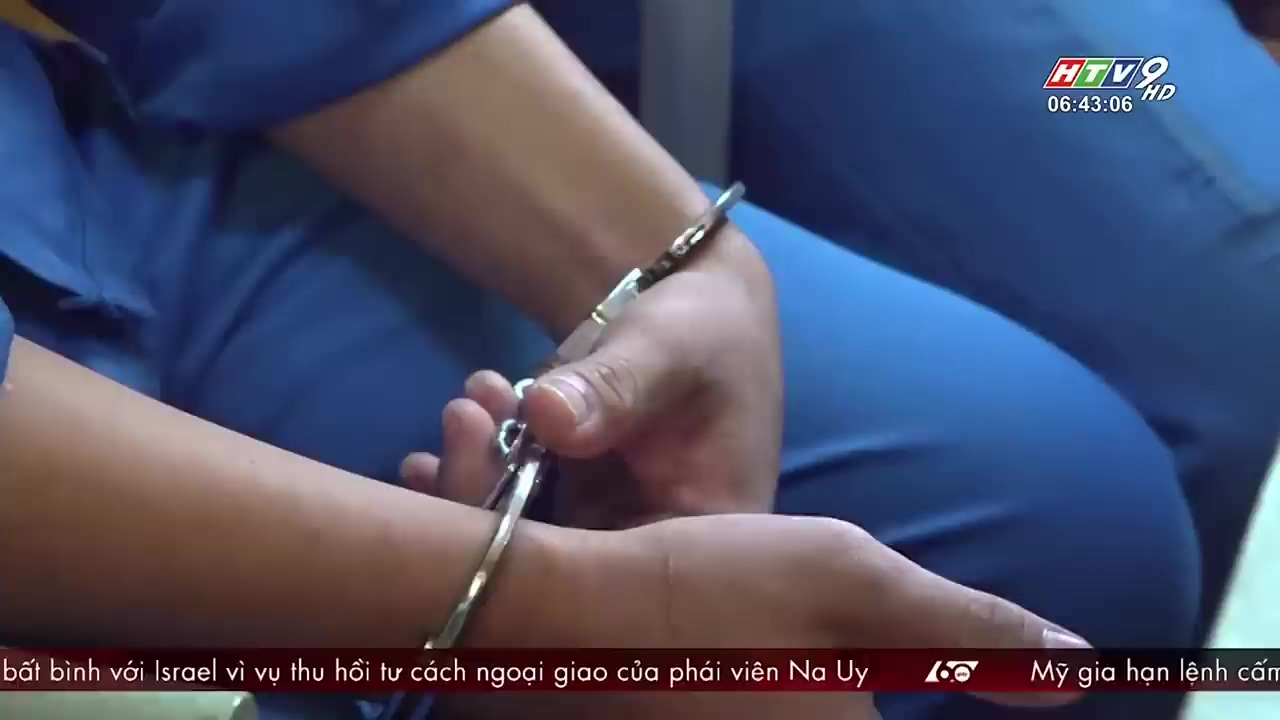

In [7]:
print("VIDEO: L21_009")
display(Image(filename="pic/148.jpg", width=250))

VIDEO: L21_009


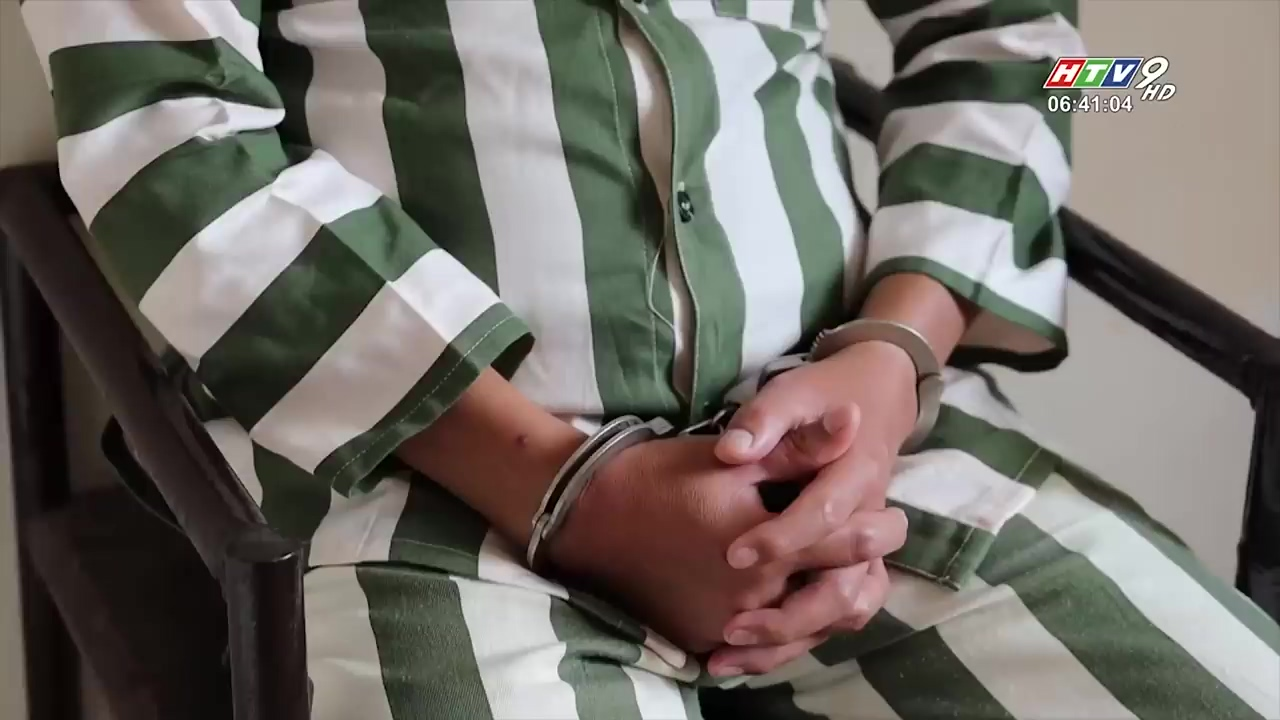

In [ ]:
print("VIDEO: L21_001")
display(Image(filename="pic/139.jpg", width=250))

VIDEO: L21_003


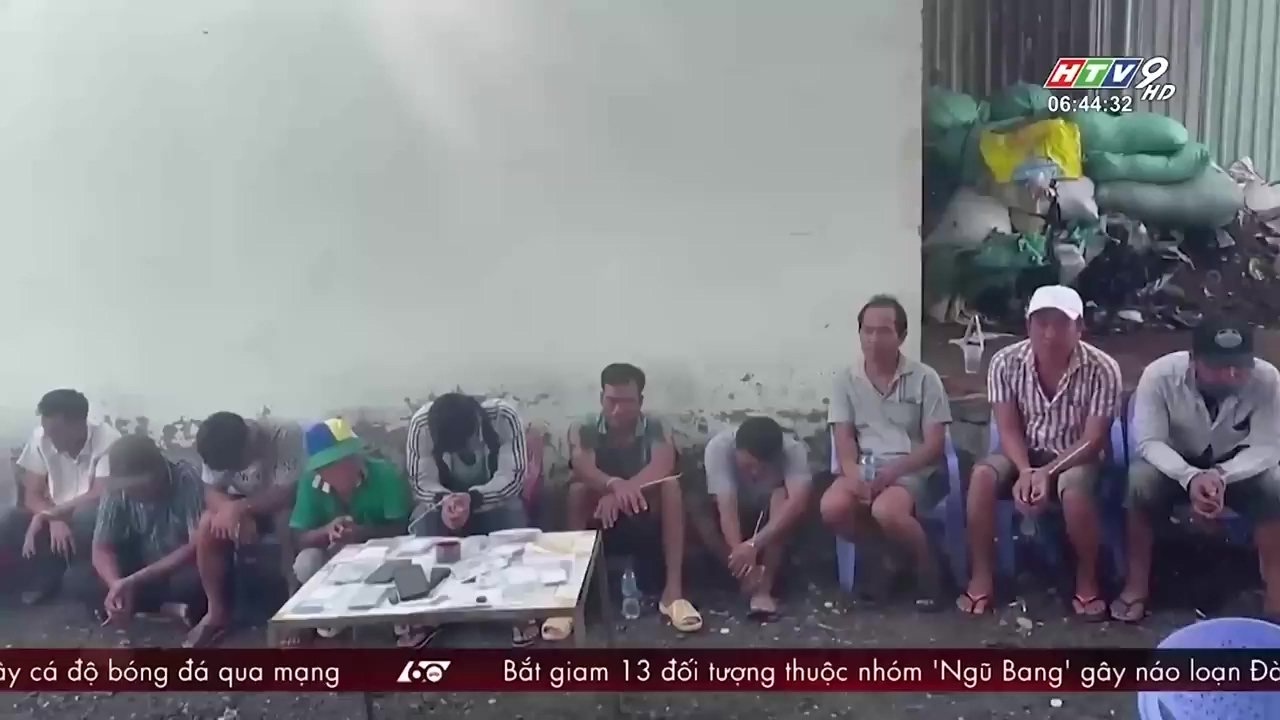

In [9]:
print("VIDEO: L21_003")
display(Image(filename="pic/175.jpg", width=250))